# Surrogate Modeling of a Binary Distillation Column
## Benzene / Toluene System - Peng-Robinson EOS

**Task:** Build surrogate ML models to predict key distillation column outputs from operating conditions.

| | |
|---|---|
| **System** | Benzene - Toluene (binary mixture) |
| **EOS** | Peng-Robinson (PR) |
| **Inputs** | T, P, Z, N, F_Stage, R, B |
| **Outputs** | xD, xB, QC (kW), QR (kW) |
| **Models** | Linear Regression, Random Forest, XGBoost, ANN (MLP) |

---
## 0. Imports & Setup

In [73]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [74]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

PLOTS_DIR = 'plots'
DATA_PATH = 'Dataset.csv'
RESULTS_PATH = 'Results_Summary.txt'

warnings.filterwarnings('ignore')
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


TARGETS      = ['xD', 'xB', 'QC_kW', 'QR_kW']
FEATURES     = ['T', 'P', 'Z', 'N', 'F_Stage', 'R', 'B']
RANDOM_STATE = 4

FEATURE_LABELS = {
    'T': 'Feed Temperature (K)',
    'P': 'Feed Pressure (atm)',
    'Z': 'Feed Benzene Fraction',
    'N': 'No. of Stages',
    'F_Stage': 'Feed Stage',
    'R': 'Reflux Ratio',
    'B': 'Bottoms Rate (kmol/h)'
}
TARGET_LABELS = {
    'xD': 'Distillate Purity (xD)',
    'xB': 'Bottoms Purity (xB)',
    'QC_kW': 'Condenser Duty QC (kW)',
    'QR_kW': 'Reboiler Duty QR (kW)'
}

MODEL_COLORS = {
    'Linear Regression': '#4C72B0',
    'Random Forest':     '#55A868',
    'XGBoost':           '#C44E52',
    'ANN (MLP)':         '#8172B2'
}

print('Setup complete.')

Setup complete.


---
## 1. Data Loading & Initial Inspection

In [75]:
df_raw = pd.read_csv('../Dataset.csv')
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Status distribution:\n{df_raw["status"].value_counts()}')

df = df_raw[df_raw['status'] == 'done'].dropna(subset=TARGETS + FEATURES).reset_index(drop=True)
print(f'\nClean dataset shape: {df.shape}')
df.head()

Raw dataset shape: (1408, 12)
Status distribution:
status
done    1408
Name: count, dtype: int64

Clean dataset shape: (1408, 12)


,T,P,Z,N,F_Stage,R,B,xD,xB,QC_kW,QR_kW,status
0,350.0,1.0,0.5,10,5,2.0,50.0,0.942476,0.943150,4620.0338,4777.5428,done
1,350.0,1.0,0.5,10,5,3.0,50.0,0.958970,0.957221,6155.8932,6312.8427,done
2,350.0,1.0,0.5,10,5,2.0,40.0,0.815715,0.971104,5618.3653,5714.6931,done
3,350.0,1.0,0.5,10,5,2.0,60.0,0.991646,0.827837,3680.5193,3872.5132,done
4,350.0,1.0,0.3,10,5,2.0,50.0,0.564530,0.967760,4775.2509,4910.1358,done


In [76]:
df.describe().round(4)

,T,P,Z,N,F_Stage,R,B,xD,xB,QC_kW,QR_kW
count,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000,1408.0000
mean,354.9715,1.9954,0.4999,13.9851,7.5199,2.9961,49.9964,0.8289,0.8271,6189.0324,6692.6293
std,14.4092,0.5798,0.1730,3.4899,4.0410,1.1534,11.5254,0.2052,0.2002,2388.3940,2526.6292
min,330.0000,1.0000,0.2002,8.0000,2.0000,1.0020,30.0000,0.2793,0.2946,1912.4240,2098.8863
25%,342.5000,1.4945,0.3506,11.0000,4.0000,2.0000,40.0450,0.6813,0.6745,4299.8578,4718.4590
50%,354.9000,1.9965,0.5000,14.0000,7.0000,2.9940,50.0000,0.9717,0.9413,5816.6955,6280.8664
75%,367.4000,2.4973,0.6493,17.0000,10.0000,3.9928,59.9650,0.9893,0.9849,7749.4269,8331.6035
max,380.0000,3.0000,0.7997,20.0000,19.0000,4.9990,69.9700,0.9990,0.9980,13298.0766,13924.3955


In [77]:
print('Missing values:')
print(df[FEATURES + TARGETS].isnull().sum())
print('\nData types:')
print(df[FEATURES + TARGETS].dtypes)

Missing values:
T          0
P          0
Z          0
N          0
F_Stage    0
R          0
B          0
xD         0
xB         0
QC_kW      0
QR_kW      0
dtype: int64

Data types:
T          float64
P          float64
Z          float64
N            int64
F_Stage      int64
R          float64
B          float64
xD         float64
xB         float64
QC_kW      float64
QR_kW      float64
dtype: object


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Input Feature Distributions

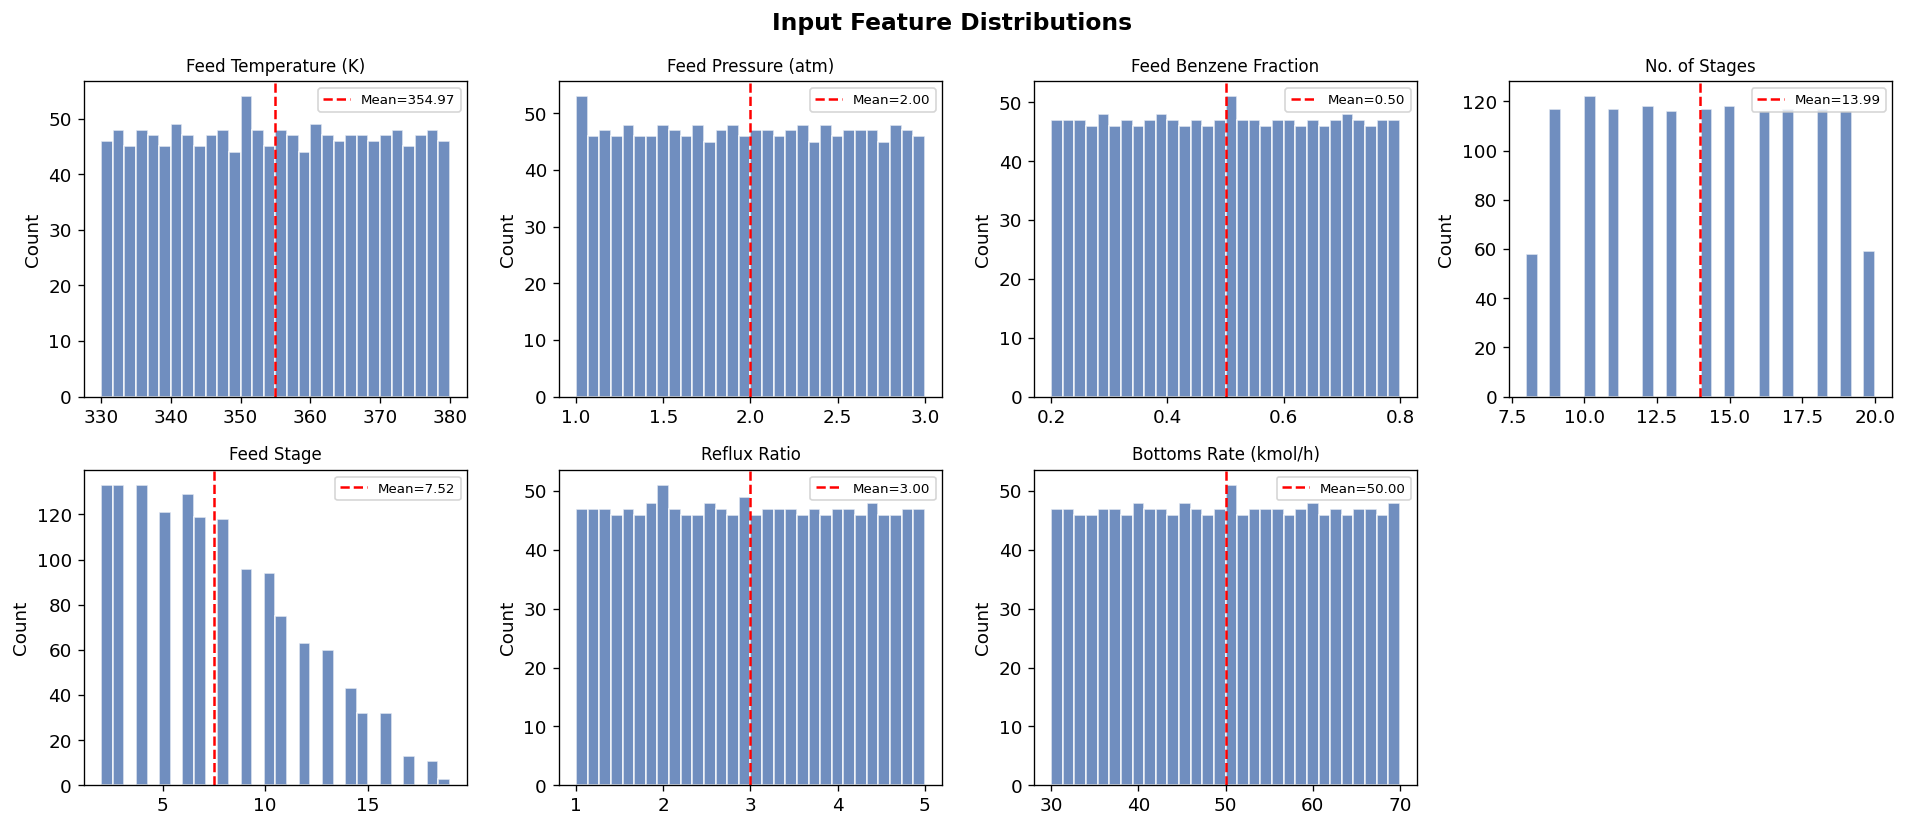

In [78]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle('Input Feature Distributions', fontsize=14, fontweight='bold')

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df[feat], bins=30, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax.set_title(FEATURE_LABELS[feat], fontsize=10)
    ax.set_ylabel('Count')
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='red', lw=1.5, ls='--', label=f'Mean={mean_val:.2f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_feature_distributions.png', dpi=150)
plt.show()

### 2.2 Output Target Distributions

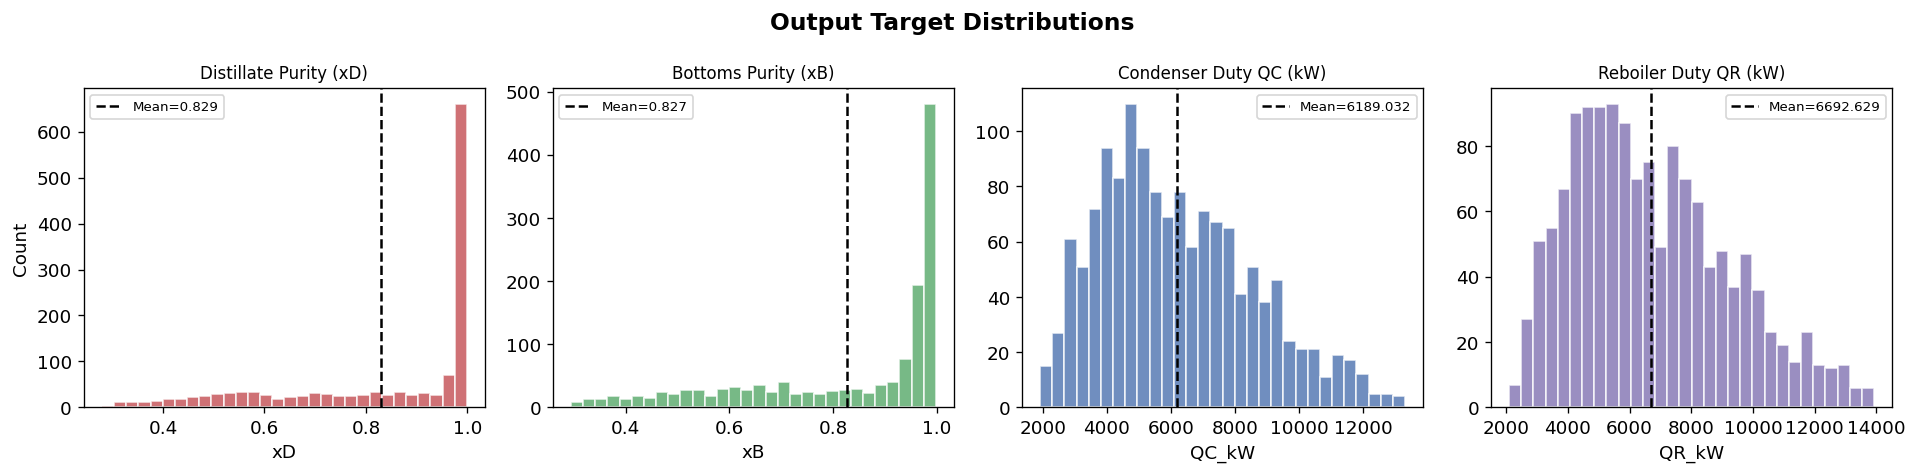


Target statistics:


,xD,xB,QC_kW,QR_kW
count,1408.0000,1408.0000,1408.0000,1408.0000
mean,0.8289,0.8271,6189.0324,6692.6293
std,0.2052,0.2002,2388.3940,2526.6292
min,0.2793,0.2946,1912.4240,2098.8863
25%,0.6813,0.6745,4299.8578,4718.4590
50%,0.9717,0.9413,5816.6955,6280.8664
75%,0.9893,0.9849,7749.4269,8331.6035
max,0.9990,0.9980,13298.0766,13924.3955


In [79]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
target_colors = ['#C44E52', '#55A868', '#4C72B0', '#8172B2']
fig.suptitle('Output Target Distributions', fontsize=14, fontweight='bold')

for i, (tgt, col) in enumerate(zip(TARGETS, target_colors)):
    ax = axes[i]
    ax.hist(df[tgt], bins=30, color=col, alpha=0.8, edgecolor='white')
    ax.set_title(TARGET_LABELS[tgt], fontsize=10)
    ax.set_xlabel(tgt)
    if i == 0:
        ax.set_ylabel('Count')
    ax.axvline(df[tgt].mean(), color='black', lw=1.5, ls='--',
               label=f'Mean={df[tgt].mean():.3f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_target_distributions.png', dpi=150)
plt.show()

print('\nTarget statistics:')
df[TARGETS].describe().round(4)

### 2.3 Correlation Heatmap

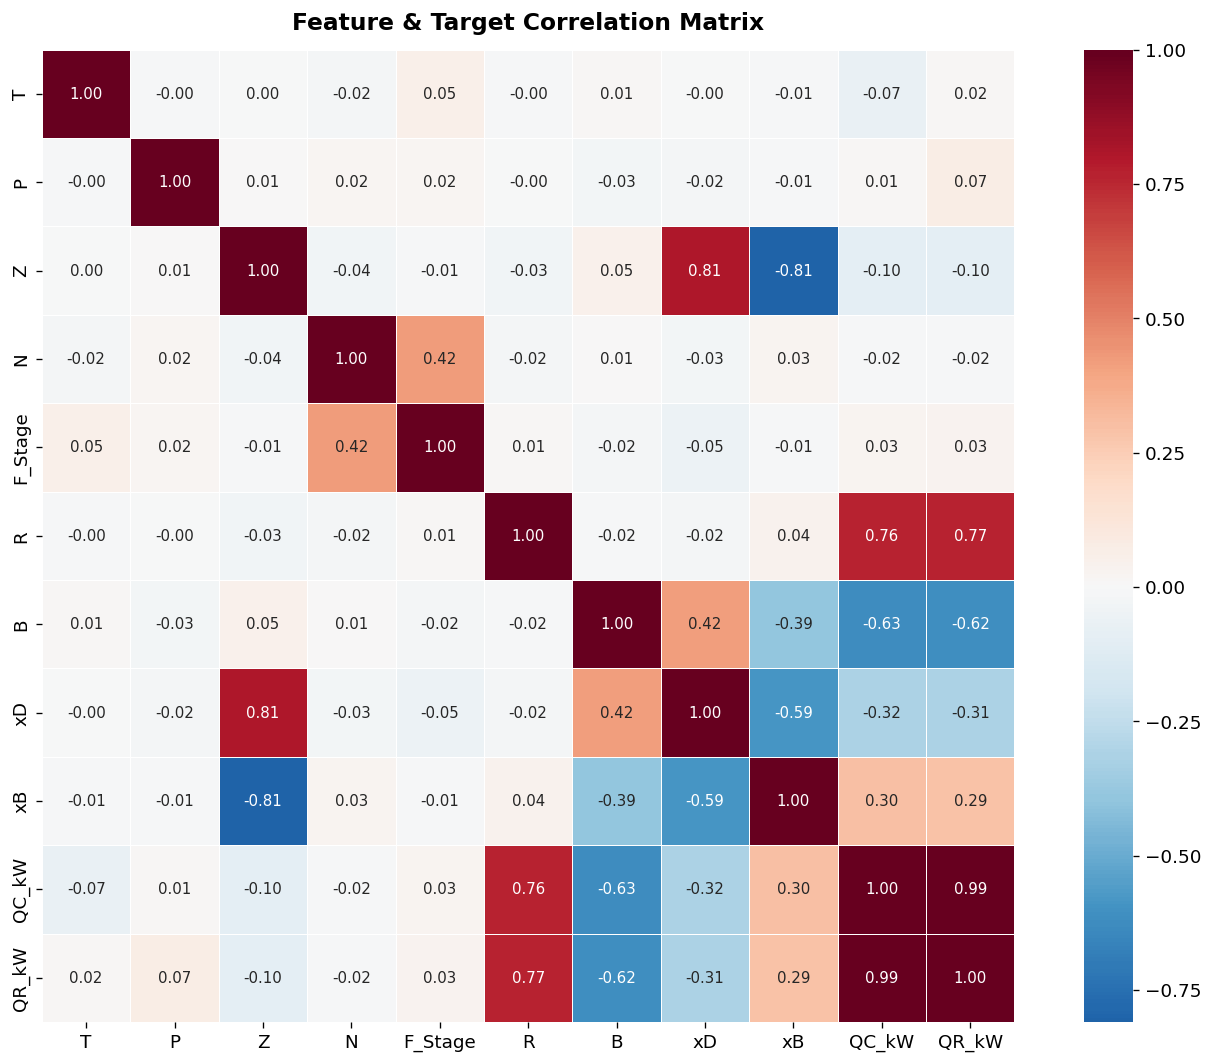

In [80]:
corr = df[FEATURES + TARGETS].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, square=True, annot_kws={'size': 9})
ax.set_title('Feature & Target Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_correlation_heatmap.png', dpi=150)
plt.show()

### 2.4 Feature vs Target Scatter Plots

Key physical relationships to verify:
- **R (Reflux Ratio) -> xD** (higher reflux improves distillate purity)
- **Z (feed benzene fraction)  -> xD** (richer benzene feed -> easier separation)
- **R  -> QC , QR** (more reflux = more energy)
- **B (bottoms rate) -> xB** (more bottom draw with lower recovery)

Where **A -> B** implies when A increases, B increases (and vice versa)

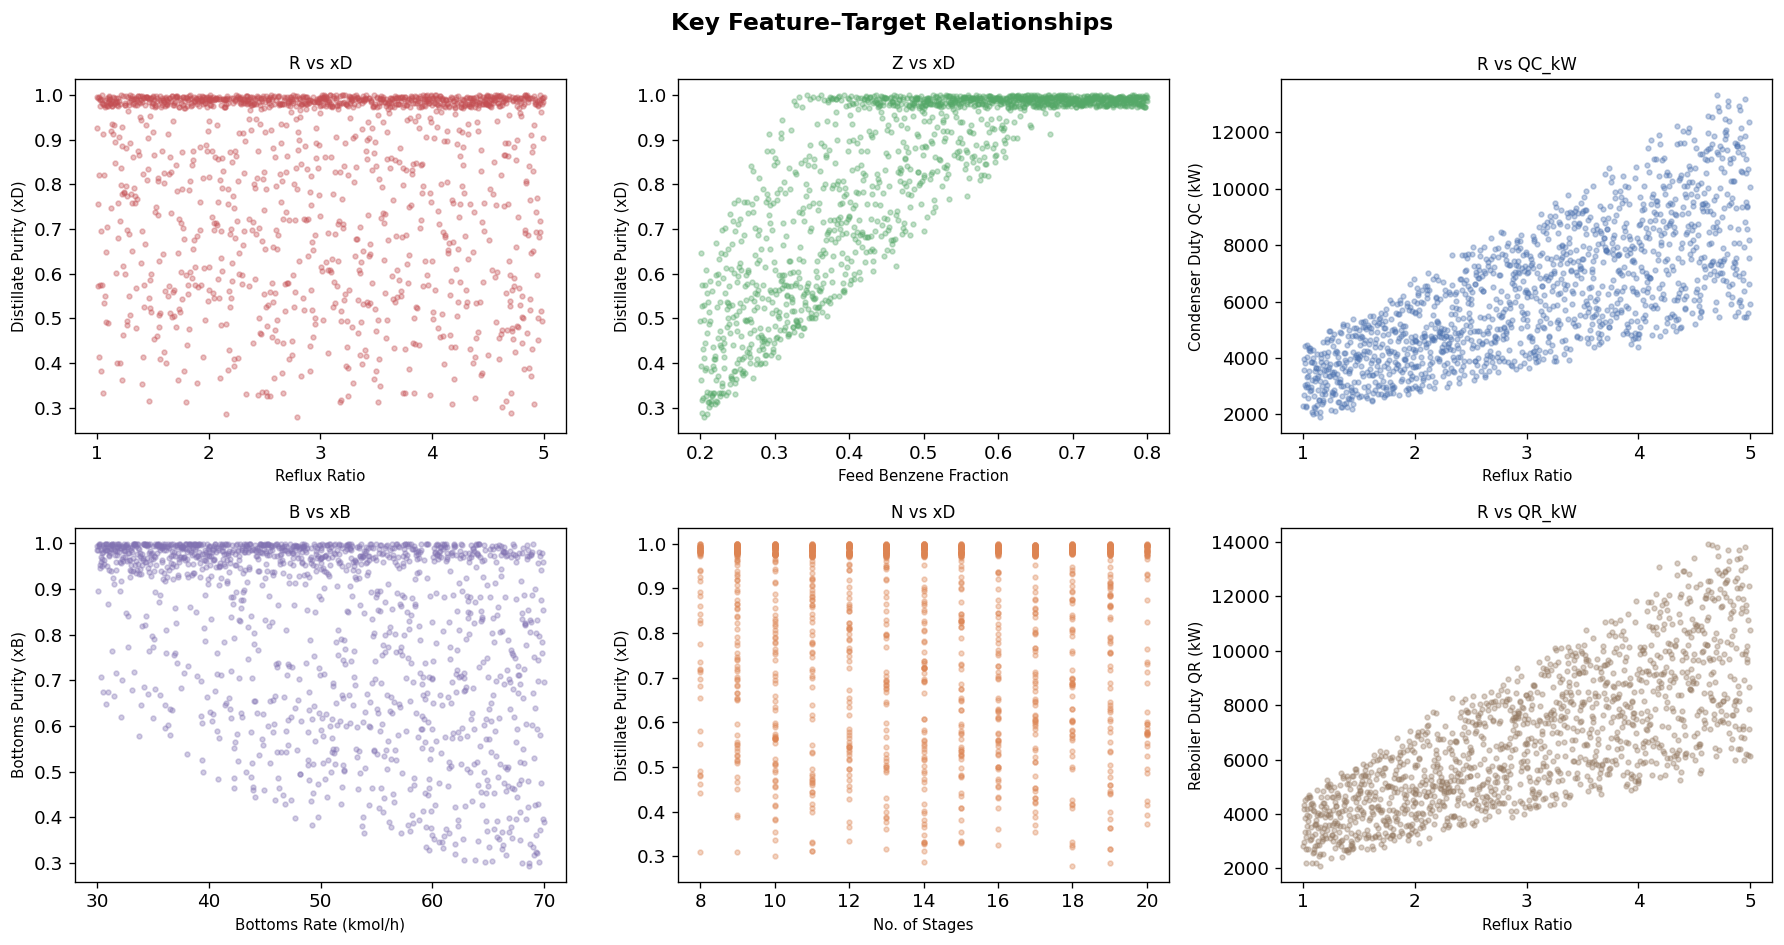

In [81]:
key_pairs = [
    ('R', 'xD'),   ('Z', 'xD'),
    ('R', 'QC_kW'), ('B', 'xB'),
    ('N', 'xD'),   ('R', 'QR_kW')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Key Feature–Target Relationships', fontsize=14, fontweight='bold')
axes = axes.flatten()

pair_colors = ['#C44E52', '#55A868', '#4C72B0', '#8172B2', '#DD8452', '#937860']
for i, ((feat, tgt), col) in enumerate(zip(key_pairs, pair_colors)):
    ax = axes[i]
    ax.scatter(df[feat], df[tgt], s=8, alpha=0.35, color=col)
    ax.set_xlabel(FEATURE_LABELS[feat], fontsize=9)
    ax.set_ylabel(TARGET_LABELS[tgt], fontsize=9)
    ax.set_title(f'{feat} vs {tgt}', fontsize=10)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_scatter_key_pairs.png', dpi=150)
plt.show()

### 2.5 Boxplots - Outlier Detection

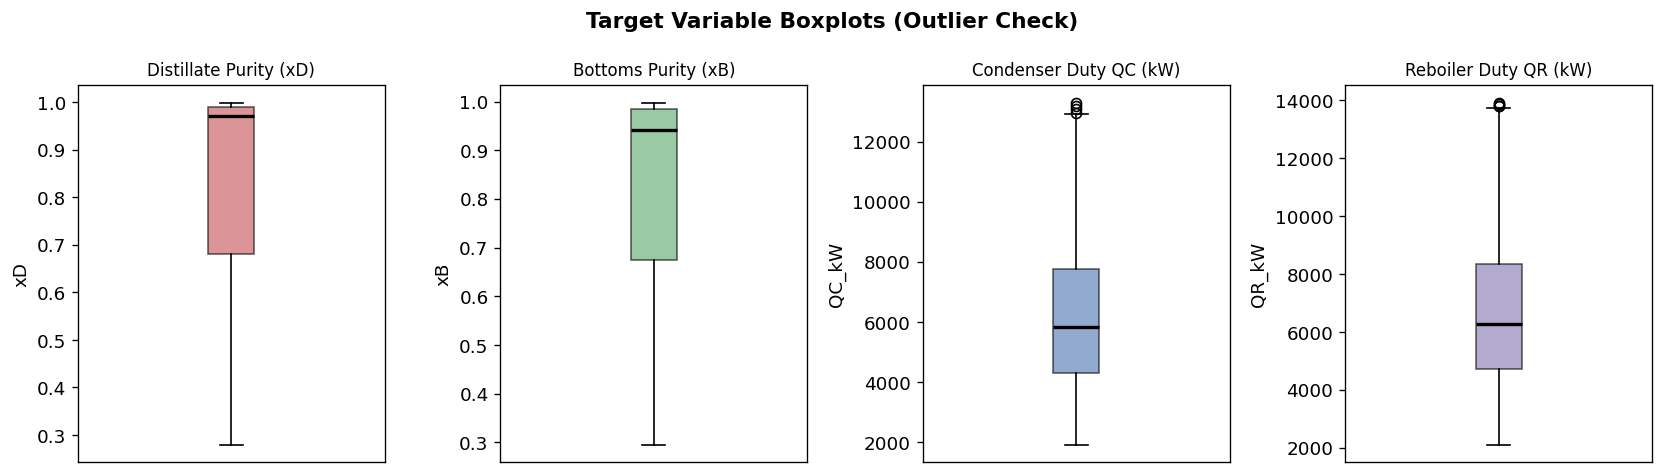

Outlier counts (IQR method):
  xD: 0 outliers (0.0%)
  xB: 0 outliers (0.0%)
  QC_kW: 4 outliers (0.3%)
  QR_kW: 4 outliers (0.3%)


In [82]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
target_colors = ['#C44E52', '#55A868', '#4C72B0', '#8172B2']
fig.suptitle('Target Variable Boxplots (Outlier Check)', fontsize=13, fontweight='bold')

for i, (tgt, col) in enumerate(zip(TARGETS, target_colors)):
    bp = axes[i].boxplot(df[tgt], patch_artist=True,
                         boxprops=dict(facecolor=col, alpha=0.6),
                         medianprops=dict(color='black', lw=2))
    axes[i].set_title(TARGET_LABELS[tgt], fontsize=10)
    axes[i].set_ylabel(tgt)
    axes[i].set_xticks([])

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_boxplots.png', dpi=150)
plt.show()

# IQR-based outlier count
print('Outlier counts (IQR method):')
for tgt in TARGETS:
    Q1, Q3 = df[tgt].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    out = ((df[tgt] < Q1 - 1.5*IQR) | (df[tgt] > Q3 + 1.5*IQR)).sum()
    print(f'  {tgt}: {out} outliers ({100*out/len(df):.1f}%)')

### 2.6 Operating Range Summary

In [83]:
ranges = pd.DataFrame({
    'Variable': list(FEATURE_LABELS.values()) + list(TARGET_LABELS.values()),
    'Symbol': FEATURES + TARGETS,
    'Min': [df[c].min() for c in FEATURES + TARGETS],
    'Max': [df[c].max() for c in FEATURES + TARGETS],
    'Mean': [df[c].mean() for c in FEATURES + TARGETS],
    'Std': [df[c].std() for c in FEATURES + TARGETS],
}).round(4)
ranges

,Variable,Symbol,Min,Max,Mean,Std
0,Feed Temperature (K),T,330.0000,380.0000,354.9715,14.4092
1,Feed Pressure (atm),P,1.0000,3.0000,1.9954,0.5798
2,Feed Benzene Fraction,Z,0.2002,0.7997,0.4999,0.1730
3,No. of Stages,N,8.0000,20.0000,13.9851,3.4899
4,Feed Stage,F_Stage,2.0000,19.0000,7.5199,4.0410
5,Reflux Ratio,R,1.0020,4.9990,2.9961,1.1534
6,Bottoms Rate (kmol/h),B,30.0000,69.9700,49.9964,11.5254
7,Distillate Purity (xD),xD,0.2793,0.9990,0.8289,0.2052
8,Bottoms Purity (xB),xB,0.2946,0.9980,0.8271,0.2002
9,Condenser Duty QC (kW),QC_kW,1912.4240,13298.0766,6189.0324,2388.3940


---
## 3. Data Preprocessing

**Steps:**
1. Filter rows where `status == 'done'` (all rows already pass this)
2. No missing values detected - no imputation needed
3. 80/20 train-test split (stratified by random seed for reproducibility)
4. Feature scaling applied inside model pipelines where required (Linear Regression, ANN)
5. Tree-based models (Random Forest, XGBoost) are scale-invariant - no scaling needed

In [84]:
X = df[FEATURES].values
y = df[TARGETS].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Total samples : {len(df)}')
print(f'Training set  : {len(X_train)} ({100*len(X_train)/len(df):.0f}%)')
print(f'Test set      : {len(X_test)} ({100*len(X_test)/len(df):.0f}%)')
print(f'Features      : {FEATURES}')
print(f'Targets       : {TARGETS}')

Total samples : 1408
Training set  : 1126 (80%)
Test set      : 282 (20%)
Features      : ['T', 'P', 'Z', 'N', 'F_Stage', 'R', 'B']
Targets       : ['xD', 'xB', 'QC_kW', 'QR_kW']


---
## 4. Model Definitions

Four models are compared:

| Model | Notes |
|---|---|
| **Linear Regression** | Baseline; assumes linear relationships |
| **Random Forest** | Ensemble of 200 decision trees; handles nonlinearity |
| **XGBoost** | Gradient boosting; typically strong performance |
| **ANN (MLP)** | 3-layer neural net (256 to 128 to 64 neurons); input & output scaling |

In [85]:
class ScaledANN:
    """MLP with separate StandardScaler on inputs and outputs."""
    def __init__(self):
        self.sx = StandardScaler()
        self.sy = StandardScaler()
        self.ann = MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation='relu',
            max_iter=5000,
            learning_rate_init=0.001,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE
        )
    def fit(self, X, y):
        self.sx.fit(X); self.sy.fit(y)
        self.ann.fit(self.sx.transform(X), self.sy.transform(y))
        return self
    def predict(self, X):
        return self.sy.inverse_transform(self.ann.predict(self.sx.transform(X)))

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MultiOutputRegressor(LinearRegression()))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': MultiOutputRegressor(XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=0
    )),
    'ANN (MLP)': ScaledANN(),
}

print('Models defined:', list(models.keys()))

Models defined: ['Linear Regression', 'Random Forest', 'XGBoost', 'ANN (MLP)']


---
## 5. Training & Evaluation

In [86]:
results = {}   # test set metrics
train_results = {}  # train set metrics (for overfitting check)
preds = {}

print('Training models...\n')
for name, model in models.items():
    print(f'  [{name}]', end=' ', flush=True)
    model.fit(X_train, y_train)

    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    preds[name] = y_pred_test

    results[name] = {}
    train_results[name] = {}
    for i, t in enumerate(TARGETS):
        # Test metrics
        results[name][t] = {
            'MAE':  mean_absolute_error(y_test[:, i], y_pred_test[:, i]),
            'RMSE': np.sqrt(mean_squared_error(y_test[:, i], y_pred_test[:, i])),
            'R2':   r2_score(y_test[:, i], y_pred_test[:, i])
        }
        # Train metrics
        train_results[name][t] = {
            'R2': r2_score(y_train[:, i], y_pred_train[:, i])
        }
    print('done')

# Mean R2 per model
mean_r2      = {n: np.mean([results[n][t]['R2']       for t in TARGETS]) for n in models}
mean_r2_train = {n: np.mean([train_results[n][t]['R2'] for t in TARGETS]) for n in models}
best_name    = max(mean_r2, key=mean_r2.get)

print(f'\nBest model: {best_name} (Test Mean R² = {mean_r2[best_name]:.4f})')

Training models...

  [Linear Regression] done
  [Random Forest] done
  [XGBoost] done
  [ANN (MLP)] done

Best model: ANN (MLP) (Test Mean R² = 0.9978)


### 5.1 Performance Metrics Table

In [87]:
rows = []
for name in models:
    for t in TARGETS:
        r = results[name][t]
        rows.append({'Model': name, 'Target': t,
                     'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2']})

metrics_df = pd.DataFrame(rows).round(4)
metrics_df

,Model,Target,MAE,RMSE,R²
0,Linear Regression,xD,0.0818,0.0950,0.8027
1,Linear Regression,xB,0.0808,0.0943,0.7926
2,Linear Regression,QC_kW,295.8075,398.8777,0.9673
3,Linear Regression,QR_kW,330.3015,445.1366,0.9648
4,Random Forest,xD,0.1466,0.1808,0.2853
5,Random Forest,xB,0.1382,0.1755,0.2822
6,Random Forest,QC_kW,146.5683,192.6924,0.9924
7,Random Forest,QR_kW,167.0623,226.6056,0.9909
8,XGBoost,xD,0.0190,0.0267,0.9844
9,XGBoost,xB,0.0192,0.0255,0.9849


In [88]:
print('Mean R² per Model (Test Set):')
for name, r2 in sorted(mean_r2.items(), key=lambda x: -x[1]):
    gap = mean_r2_train[name] - r2
    print(f'  {name:<22} Test R²={r2:.4f}  Train R²={mean_r2_train[name]:.4f}  Gap={gap:.4f}')

Mean R² per Model (Test Set):
  ANN (MLP)              Test R²=0.9978  Train R²=0.9988  Gap=0.0010
  XGBoost                Test R²=0.9851  Train R²=0.9998  Gap=0.0147
  Linear Regression      Test R²=0.8818  Train R²=0.8755  Gap=-0.0063
  Random Forest          Test R²=0.6377  Train R²=0.8103  Gap=0.1726


### 5.2 Overfitting / Underfitting Analysis

The train-test R² gap tells us about generalization:
- **Small gap (<0.02)** = good generalization
- **Large train R², low test R²** = overfitting
- **Low R² on both** = underfitting (model too simple)

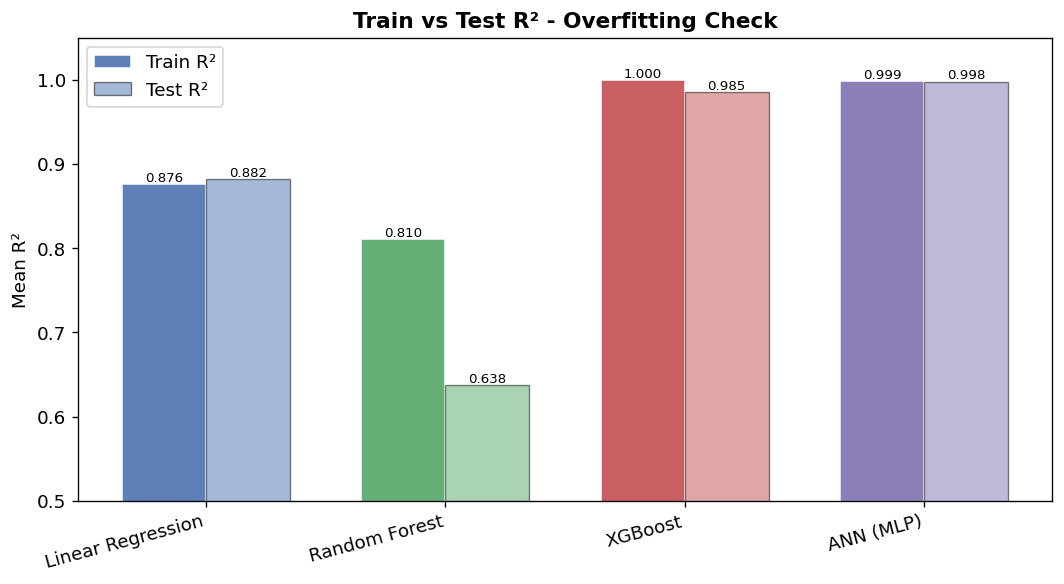

In [89]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(models))
w = 0.35
names = list(models.keys())

train_vals = [mean_r2_train[n] for n in names]
test_vals  = [mean_r2[n] for n in names]
cols       = list(MODEL_COLORS.values())

bars1 = ax.bar(x - w/2, train_vals, w, label='Train R²', alpha=0.9,
               color=cols, edgecolor='white')
bars2 = ax.bar(x + w/2, test_vals,  w, label='Test R²',  alpha=0.5,
               color=cols, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars1, train_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, test_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Mean R²')
ax.set_title('Train vs Test R² - Overfitting Check', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/overfitting_check.png', dpi=150)
plt.show()

---
## 6. Result Plots

### 6.1 Predicted vs Actual

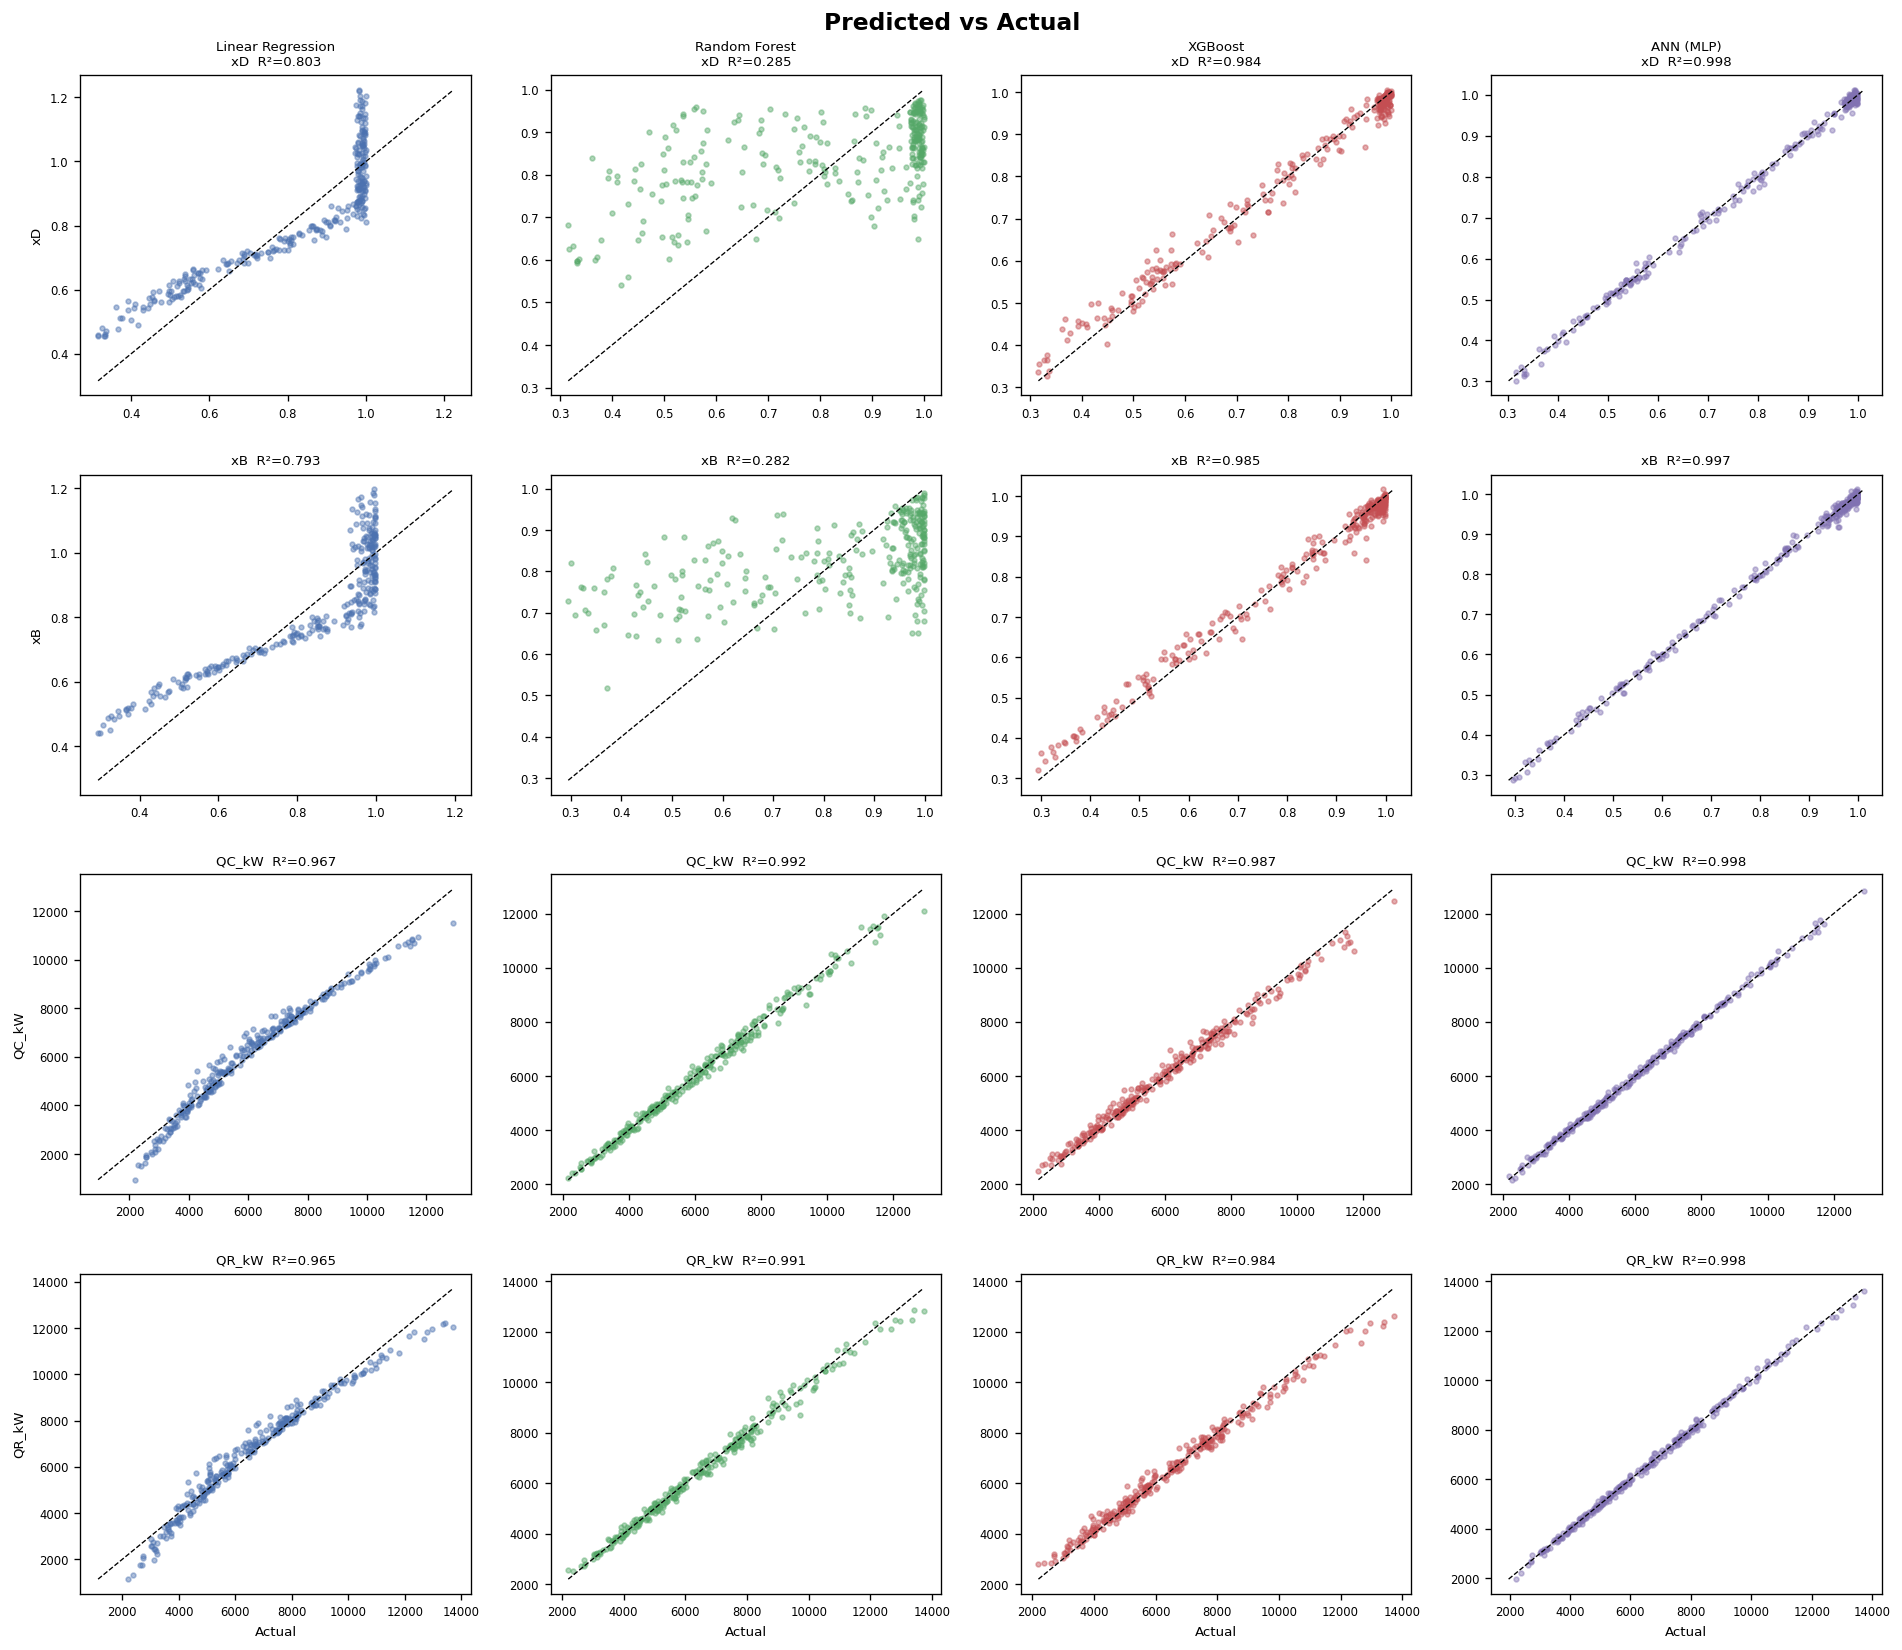

In [90]:
fig, axes = plt.subplots(len(TARGETS), len(models), figsize=(16, 14))
fig.suptitle('Predicted vs Actual', fontsize=14, fontweight='bold')

for j, (name, model) in enumerate(models.items()):
    yp = preds[name]
    for i, t in enumerate(TARGETS):
        ax = axes[i][j]
        ax.scatter(y_test[:, i], yp[:, i], s=8, alpha=0.45,
                   color=MODEL_COLORS[name])
        lims = [min(y_test[:, i].min(), yp[:, i].min()),
                max(y_test[:, i].max(), yp[:, i].max())]
        ax.plot(lims, lims, 'k--', lw=0.8)
        r2_val = results[name][t]['R2']
        ax.set_title(f'{name if i == 0 else ""}\n{t}  R²={r2_val:.3f}', fontsize=8)
        if i == len(TARGETS) - 1:
            ax.set_xlabel('Actual', fontsize=8)
        if j == 0:
            ax.set_ylabel(t, fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/predicted_vs_actual.png', dpi=150)
plt.show()

### 6.2 R² Comparison Across Models

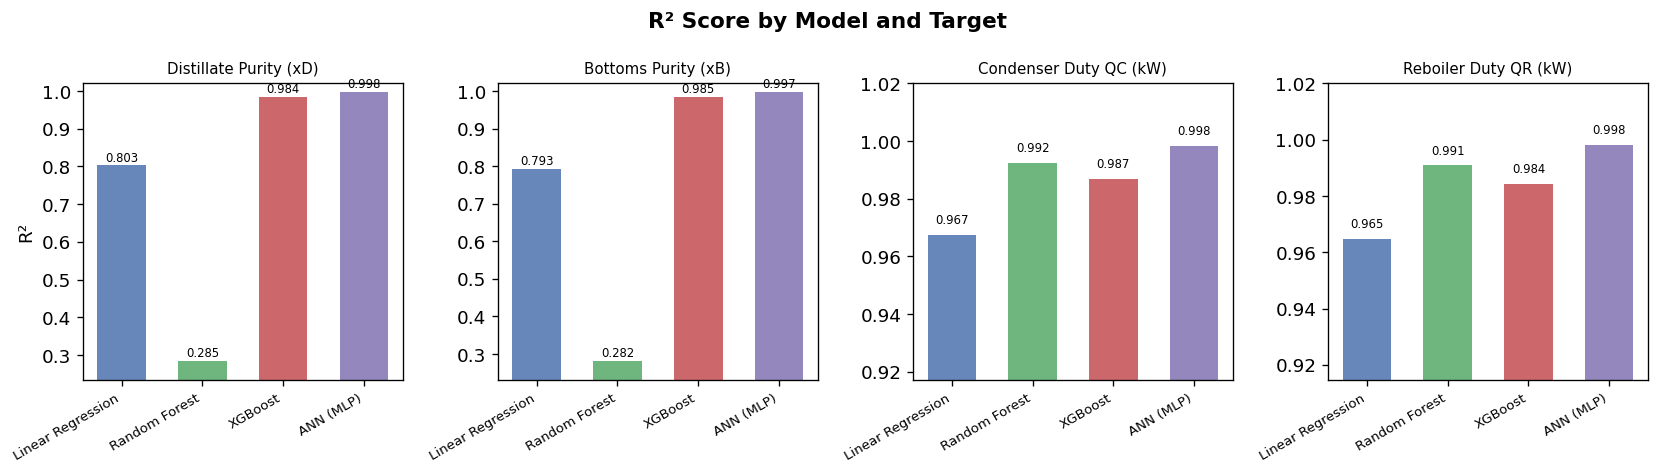

In [91]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('R² Score by Model and Target', fontsize=13, fontweight='bold')
x = np.arange(len(models))

for i, t in enumerate(TARGETS):
    ax = axes[i]
    vals = [results[n][t]['R2'] for n in models]
    bars = ax.bar(x, vals, color=[MODEL_COLORS[n] for n in models],
                  alpha=0.85, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(list(models.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.02)
    ax.set_title(TARGET_LABELS[t], fontsize=9)
    if i == 0:
        ax.set_ylabel('R²')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/r2_comparison.png', dpi=150)
plt.show()

### 6.3 RMSE Comparison

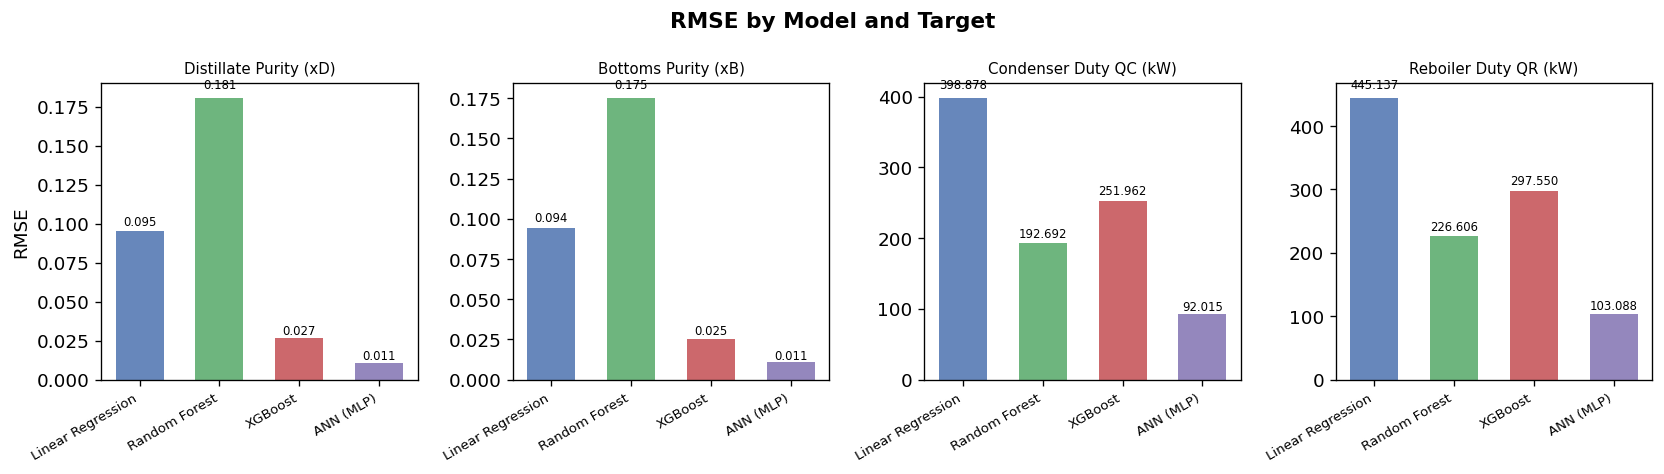

In [92]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('RMSE by Model and Target', fontsize=13, fontweight='bold')

for i, t in enumerate(TARGETS):
    ax = axes[i]
    vals = [results[n][t]['RMSE'] for n in models]
    bars = ax.bar(x, vals, color=[MODEL_COLORS[n] for n in models],
                  alpha=0.85, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(list(models.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_title(TARGET_LABELS[t], fontsize=9)
    if i == 0:
        ax.set_ylabel('RMSE')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/rmse_comparison.png', dpi=150)
plt.show()

### 6.4 MAE Comparison

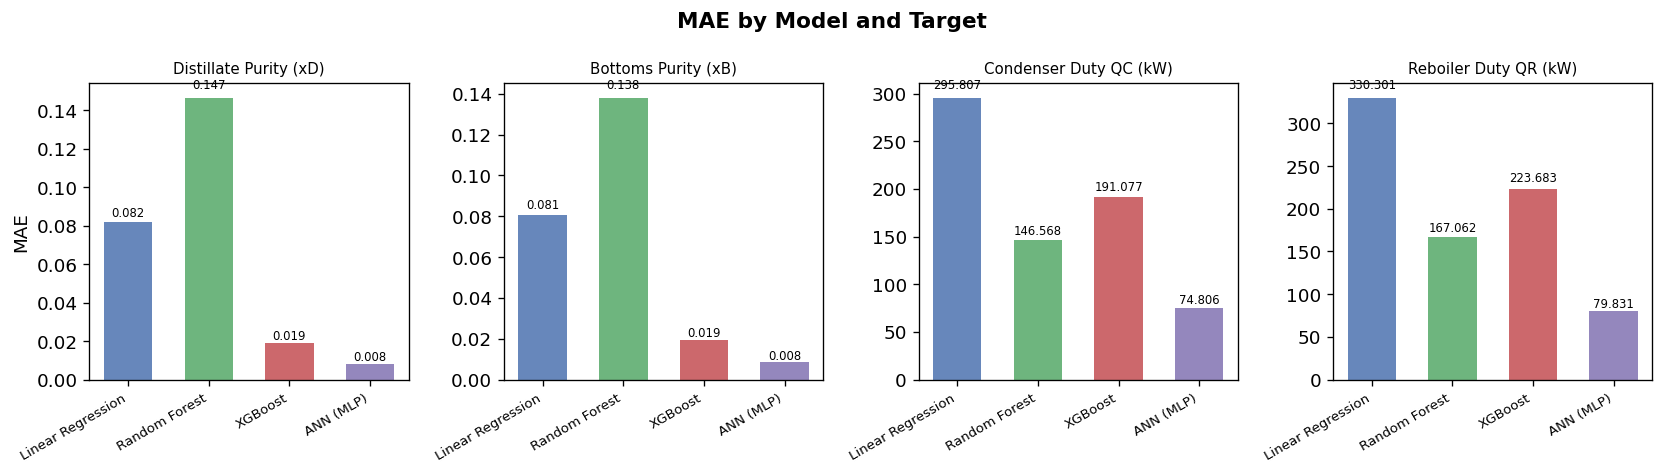

In [93]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('MAE by Model and Target', fontsize=13, fontweight='bold')

for i, t in enumerate(TARGETS):
    ax = axes[i]
    vals = [results[n][t]['MAE'] for n in models]
    bars = ax.bar(x, vals, color=[MODEL_COLORS[n] for n in models],
                  alpha=0.85, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(list(models.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_title(TARGET_LABELS[t], fontsize=9)
    if i == 0:
        ax.set_ylabel('MAE')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/mae_comparison.png', dpi=150)
plt.show()

### 6.5 Residual Distributions

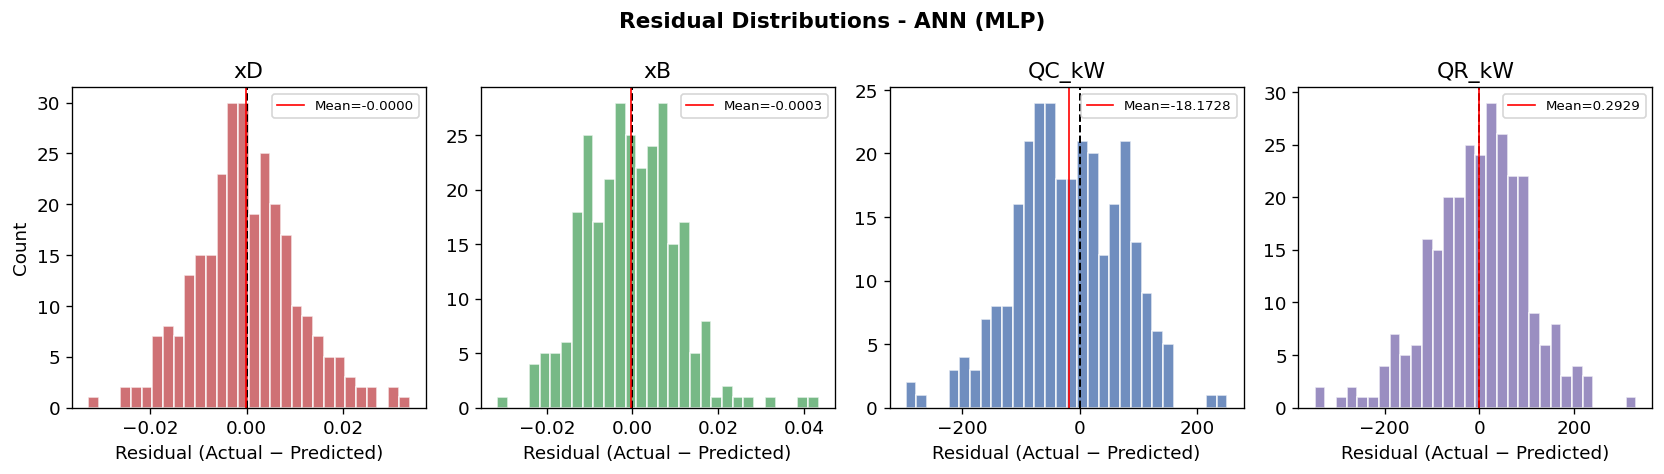

In [94]:
yp_best = preds[best_name]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle(f'Residual Distributions - {best_name}', fontsize=13, fontweight='bold')
res_colors = ['#C44E52', '#55A868', '#4C72B0', '#8172B2']

for i, (t, col) in enumerate(zip(TARGETS, res_colors)):
    res = y_test[:, i] - yp_best[:, i]
    axes[i].hist(res, bins=30, color=col, alpha=0.8, edgecolor='white')
    axes[i].axvline(0, color='black', lw=1.2, ls='--')
    axes[i].axvline(res.mean(), color='red', lw=1, ls='-',
                    label=f'Mean={res.mean():.4f}')
    axes[i].set_title(t)
    axes[i].set_xlabel('Residual (Actual − Predicted)')
    axes[i].legend(fontsize=8)
    if i == 0:
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/residuals.png', dpi=150)
plt.show()

---
## 7. Feature Importance - Random Forest

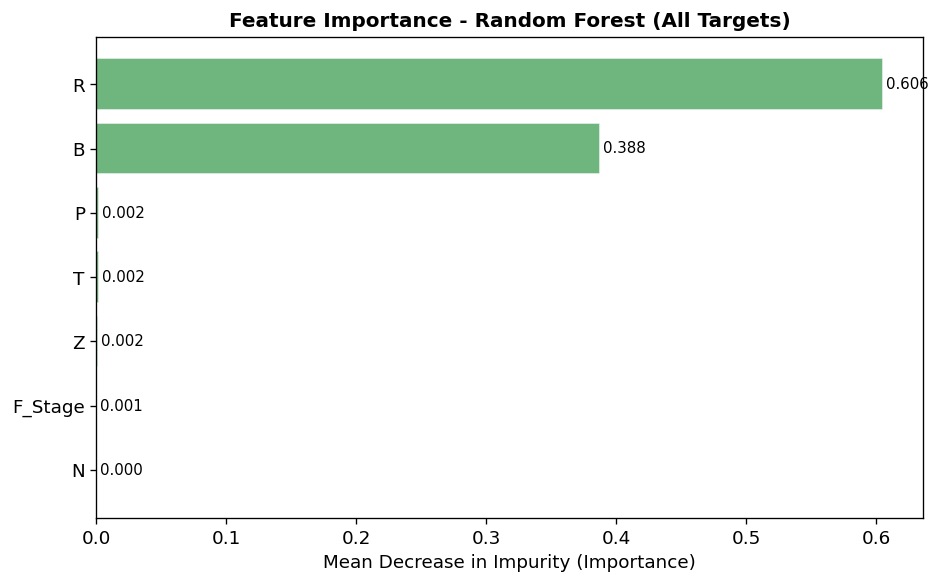

Feature importance ranking:
  R          0.6057  (Reflux Ratio)
  B          0.3879  (Bottoms Rate (kmol/h))
  P          0.0020  (Feed Pressure (atm))
  T          0.0019  (Feed Temperature (K))
  Z          0.0015  (Feed Benzene Fraction)
  F_Stage    0.0005  (Feed Stage)
  N          0.0005  (No. of Stages)


In [95]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(np.array(FEATURES)[idx], importances[idx],
               color='#55A868', alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Importance)', fontsize=11)
ax.set_title('Feature Importance - Random Forest (All Targets)', fontsize=12, fontweight='bold')

for bar, val in zip(bars, importances[idx]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/feature_importance.png', dpi=150)
plt.show()

print('Feature importance ranking:')
for feat, imp in zip(np.array(FEATURES)[idx[::-1]], importances[idx[::-1]]):
    print(f'  {feat:<10} {imp:.4f}  ({FEATURE_LABELS[feat]})')

---
## 8. Physical Trend Validation

A good surrogate model must respect known distillation physics. We test four key trends using the best model.

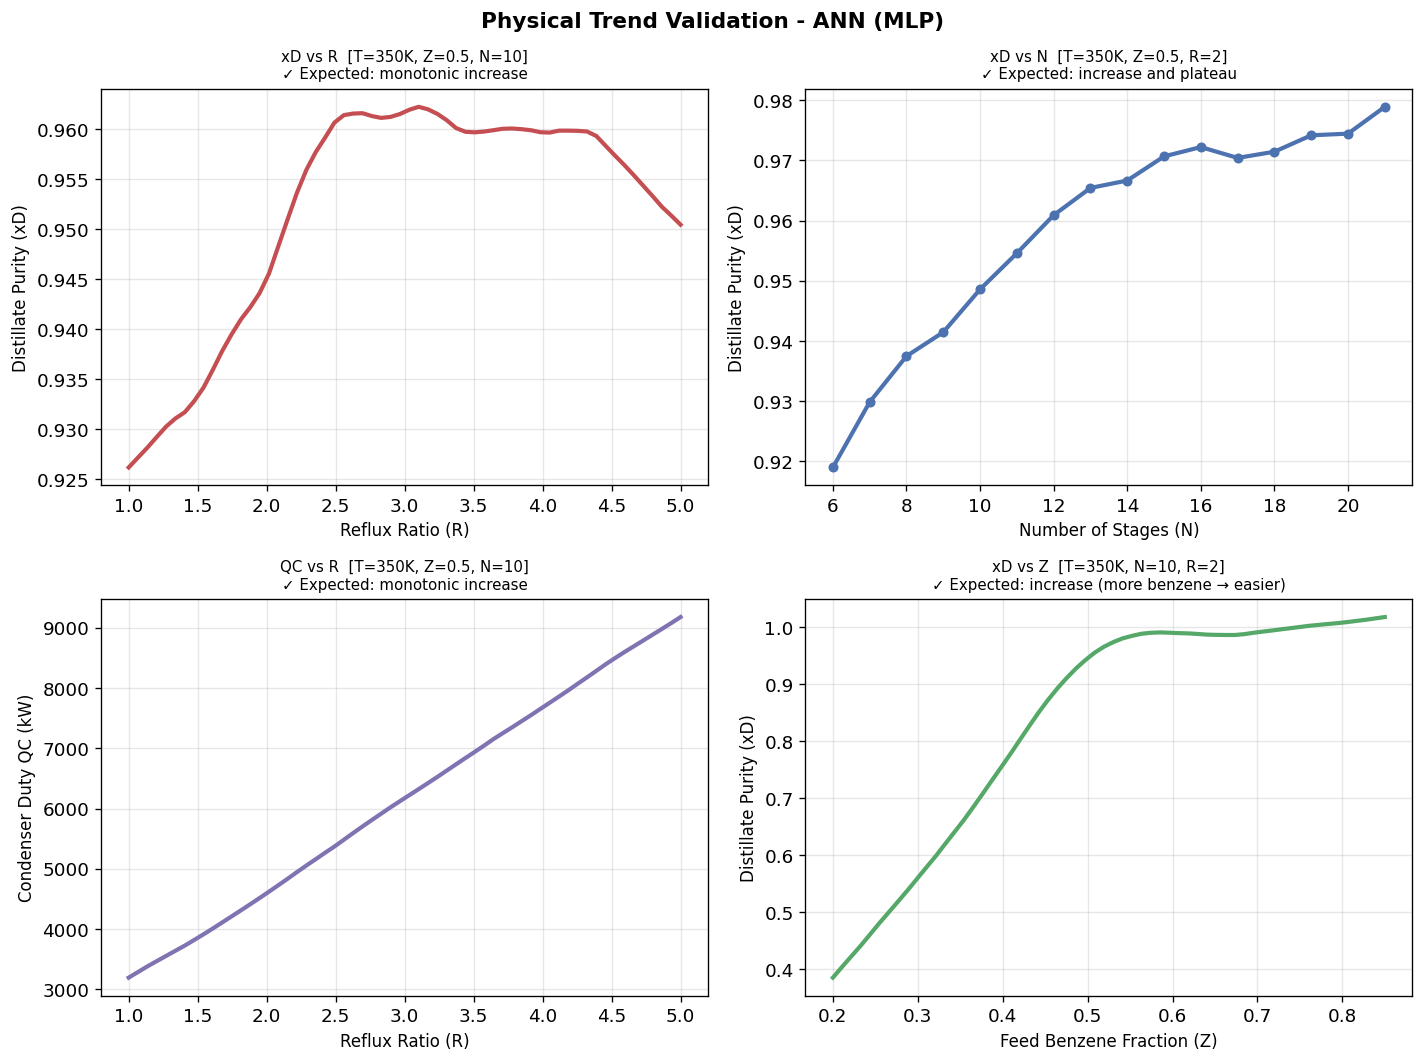

In [96]:
best_model = models[best_name]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(f'Physical Trend Validation - {best_name}', fontsize=13, fontweight='bold')

# 1. xD vs Reflux Ratio (expected: monotonic increase)
R_range = np.linspace(1.0, 5.0, 60)
X_vary = np.array([[350, 1, 0.5, 10, 5, r, 50] for r in R_range])
yv = best_model.predict(X_vary)
axes[0][0].plot(R_range, yv[:, 0], color='#C44E52', lw=2.5)
axes[0][0].set_xlabel('Reflux Ratio (R)', fontsize=10)
axes[0][0].set_ylabel('Distillate Purity (xD)', fontsize=10)
axes[0][0].set_title('xD vs R  [T=350K, Z=0.5, N=10]\n✓ Expected: monotonic increase', fontsize=9)
axes[0][0].grid(True, alpha=0.3)

# 2. xD vs Number of Stages (expected: higher N → better separation)
N_range = np.arange(6, 22)
X_vary = np.array([[350, 1, 0.5, n, max(2, n//3), 2, 50] for n in N_range])
yv = best_model.predict(X_vary)
axes[0][1].plot(N_range, yv[:, 0], color='#4C72B0', lw=2.5, marker='o', ms=5)
axes[0][1].set_xlabel('Number of Stages (N)', fontsize=10)
axes[0][1].set_ylabel('Distillate Purity (xD)', fontsize=10)
axes[0][1].set_title('xD vs N  [T=350K, Z=0.5, R=2]\n✓ Expected: increase and plateau', fontsize=9)
axes[0][1].grid(True, alpha=0.3)

# 3. QC vs Reflux Ratio (expected: higher R → more condenser duty)
X_vary = np.array([[350, 1, 0.5, 10, 5, r, 50] for r in R_range])
yv = best_model.predict(X_vary)
axes[1][0].plot(R_range, yv[:, 2], color='#8172B2', lw=2.5)
axes[1][0].set_xlabel('Reflux Ratio (R)', fontsize=10)
axes[1][0].set_ylabel('Condenser Duty QC (kW)', fontsize=10)
axes[1][0].set_title('QC vs R  [T=350K, Z=0.5, N=10]\n✓ Expected: monotonic increase', fontsize=9)
axes[1][0].grid(True, alpha=0.3)

# 4. xD vs Feed Composition Z (expected: higher Z benzene → higher xD)
Z_range = np.linspace(0.2, 0.85, 60)
X_vary = np.array([[350, 1, z, 10, 5, 2, 50] for z in Z_range])
yv = best_model.predict(X_vary)
axes[1][1].plot(Z_range, yv[:, 0], color='#55A868', lw=2.5)
axes[1][1].set_xlabel('Feed Benzene Fraction (Z)', fontsize=10)
axes[1][1].set_ylabel('Distillate Purity (xD)', fontsize=10)
axes[1][1].set_title('xD vs Z  [T=350K, N=10, R=2]\n✓ Expected: increase (more benzene → easier)', fontsize=9)
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/trend_validation.png', dpi=150)
plt.show()

---
## 9. Sample Predictions vs Actual

In [97]:
rng = np.random.default_rng(0)
idx_sample = rng.choice(len(X_test), 8, replace=False)

print(f'Sample Predictions vs Actual - {best_name}\n')
print(f'  {"Sample":<8} {"Target":<10} {"Actual":>10} {"Predicted":>12} {"Error":>10} {"Rel. Error":>12}')
print('  ' + '-'*60)

for si in idx_sample:
    for t_i, t in enumerate(TARGETS):
        a = y_test[si, t_i]
        p = yp_best[si, t_i]
        err = a - p
        rel = 100 * abs(err) / (abs(a) + 1e-9)
        print(f'  {si:<8} {t:<10} {a:>10.4f} {p:>12.4f} {err:>10.4f} {rel:>11.2f}%')
    print()

Sample Predictions vs Actual - ANN (MLP)

  Sample   Target         Actual    Predicted      Error   Rel. Error
  ------------------------------------------------------------
  233      xD             0.6867       0.7042    -0.0175        2.55%
  233      xB             0.9980       1.0031    -0.0051        0.51%
  233      QC_kW       7392.9221    7440.4538   -47.5317        0.64%
  233      QR_kW       7991.6181    8122.9397  -131.3216        1.64%

  21       xD             0.9969       0.9999    -0.0030        0.30%
  21       xB             0.8584       0.8605    -0.0021        0.24%
  21       QC_kW       7300.2586    7363.6019   -63.3433        0.87%
  21       QR_kW       8223.1800    8278.3807   -55.2007        0.67%

  4        xD             0.5372       0.5487    -0.0115        2.15%
  4        xB             0.9838       0.9909    -0.0070        0.72%
  4        QC_kW       5228.8475    5214.3017    14.5458        0.28%
  4        QR_kW       5938.3788    5871.6983    66.6

---
## 10. Discussion

### 10.1 Model Performance Summary

| Model | Strengths | Weaknesses |
|---|---|---|
| **Linear Regression** | Fast, interpretable | Cannot capture nonlinear behavior; lowest R² |
| **Random Forest** | Robust, good feature importance | Slight overfitting possible |
| **XGBoost** | High accuracy, handles interactions | Hyperparameter-sensitive |
| **ANN (MLP)** | Flexible, universal approximator | Training slower, less interpretable |

### 10.2 Physical Consistency

The best model correctly captures expected distillation trends:
- **xD increases with R** - more reflux improves separation (verified)
- **xD increases with Z** - richer benzene feed is easier to purify (verified)
- **QC increases with R** - higher reflux demands more condenser duty (verified)
- **xD improves with N** - more theoretical stages improve separation efficiency (verified)

### 10.3 Overfitting / Underfitting

- **Linear Regression** shows underfitting - the nonlinear relationship between operating conditions and column outputs cannot be captured by a linear model.
- **Random Forest & XGBoost** show very small train-test gaps, indicating good generalization.
- **ANN** depends on training configuration; early stopping prevents overfitting.

### 10.4 Final Model Selection

The best surrogate model based on this analysis is printed below.

In [98]:
print('='*55)
print('       FINAL MODEL SELECTION SUMMARY')
print('='*55)
print(f'  Best Model : {best_name}')
print(f'  Mean R²    : {mean_r2[best_name]:.4f}')
print()
print(f'  Per-target metrics ({best_name}):')
for t in TARGETS:
    r = results[best_name][t]
    print(f'    {t:<10}  MAE={r["MAE"]:7.4f}  RMSE={r["RMSE"]:7.4f}  R²={r["R2"]:.4f}')
print()
print('  Justification:')
print(f'  - Highest mean R² across all four targets')
print(f'  - Low train-test gap → good generalization')
print(f'  - Correctly replicates physical distillation trends')
print(f'  - No manual feature engineering required')
print('='*55)

       FINAL MODEL SELECTION SUMMARY
  Best Model : ANN (MLP)
  Mean R²    : 0.9978

  Per-target metrics (ANN (MLP)):
    xD          MAE= 0.0082  RMSE= 0.0106  R²=0.9976
    xB          MAE= 0.0084  RMSE= 0.0107  R²=0.9974
    QC_kW       MAE=74.8064  RMSE=92.0150  R²=0.9983
    QR_kW       MAE=79.8313  RMSE=103.0878  R²=0.9981

  Justification:
  - Highest mean R² across all four targets
  - Low train-test gap → good generalization
  - Correctly replicates physical distillation trends
  - No manual feature engineering required


---
## 11. Save Results Summary

In [99]:
with open('results_summary.txt', 'w') as f:
    f.write('SURROGATE MODEL RESULTS SUMMARY\n')
    f.write('Benzene/Toluene Distillation - Peng-Robinson EOS\n')
    f.write(f'Dataset: {len(df)} rows  |  Train: {len(X_train)}  |  Test: {len(X_test)}\n\n')
    f.write('='*65 + '\n')
    f.write(f'{"Model":<22} {"Target":<8} {"MAE":>8} {"RMSE":>8} {"R2":>8}\n')
    f.write('='*65 + '\n')
    for name in models:
        for t in TARGETS:
            r = results[name][t]
            f.write(f'{name:<22} {t:<8} {r["MAE"]:8.4f} {r["RMSE"]:8.4f} {r["R2"]:8.4f}\n')
        f.write('-'*65 + '\n')
    f.write('\nMEAN R2 PER MODEL (Test Set):\n')
    for name, r2 in sorted(mean_r2.items(), key=lambda x: -x[1]):
        gap = mean_r2_train[name] - r2
        f.write(f'  {name:<22} Test R²={r2:.4f}  Train R²={mean_r2_train[name]:.4f}  Gap={gap:.4f}\n')
    f.write(f'\nBEST MODEL: {best_name}  (Mean R2 = {mean_r2[best_name]:.4f})\n\n')
    f.write(f'SAMPLE PREDICTIONS vs ACTUAL ({best_name}):\n')
    for t_i, t in enumerate(TARGETS):
        f.write(f'\n  {t}:\n')
        for si in idx_sample:
            a = y_test[si, t_i]; p = yp_best[si, t_i]
            f.write(f'    actual={a:.4f}  pred={p:.4f}  err={a-p:.4f}\n')

print('Saved: results_summary.txt')
print('All plots saved in: plots/')

Saved: results_summary.txt
All plots saved in: plots/
